# EDA Notebook\n\nUse this notebook for exploration.

# 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

print("✅ Libraries loaded")

✅ Libraries loaded


📌 CELL 2 — Load all datasets

In [2]:
customers = pd.read_csv("../inputs/customers.csv", parse_dates=["signup_date"])
transactions = pd.read_csv("../inputs/transactions.csv", parse_dates=["transaction_date"])
events = pd.read_csv("../inputs/events.csv", parse_dates=["event_date"])
support = pd.read_csv("../inputs/support.csv", parse_dates=["ticket_date"])

customers.head()
transactions.head()
events.head()
support.head()

,customer_id,ticket_date,issue_type,resolution_days
0,3,2023-06-13,technical,1
1,8,2023-08-26,technical,2
2,10,2022-03-19,general,9
3,12,2022-06-02,general,4
4,16,2021-11-14,technical,4


📌 CELL 3 — Dataset Shapes

In [4]:
print("Customers:", customers.shape)
print("Transactions:", transactions.shape)
print("Events:", events.shape)
print("Support:", support.shape)


Customers: (3000, 6)
Transactions: (51350, 3)
Events: (107842, 3)
Support: (454, 4)


📌 CELL 4 — Missing Values Report

In [5]:
print("Missing values in Customers:\n", customers.isnull().sum(), "\n")
print("Missing values in Transactions:\n", transactions.isnull().sum(), "\n")
print("Missing values in Events:\n", events.isnull().sum(), "\n")
print("Missing values in Support:\n", support.isnull().sum(), "\n")


Missing values in Customers:
 customer_id     0
signup_date     0
plan            0
monthly_fee     0
recency_days    0
churn           0
dtype: int64 

Missing values in Transactions:
 customer_id         0
transaction_date    0
amount              0
dtype: int64 

Missing values in Events:
 customer_id    0
event_date     0
event_type     0
dtype: int64 

Missing values in Support:
 customer_id        0
ticket_date        0
issue_type         0
resolution_days    0
dtype: int64 



📌 CELL 5 — Basic Statistics

In [6]:
customers.describe(include="all")
transactions.describe(include="all")
events.describe(include="all")
support.describe(include="all")

,customer_id,ticket_date,issue_type,resolution_days
count,454.000000,454,454,454.000000
unique,NaN,NaN,3,NaN
top,NaN,NaN,technical,NaN
freq,NaN,NaN,163,NaN
mean,1563.275330,2023-03-22 06:14:16.387665152,NaN,4.303965
min,3.000000,2021-03-31 00:00:00,NaN,0.000000
25%,831.000000,2022-11-09 06:00:00,NaN,2.000000
50%,1521.000000,2023-05-22 12:00:00,NaN,4.000000
75%,2383.000000,2023-10-05 18:00:00,NaN,7.000000
max,2998.000000,2024-01-13 00:00:00,NaN,9.000000


📌 CELL 6 — Visualizing Customer Attributes

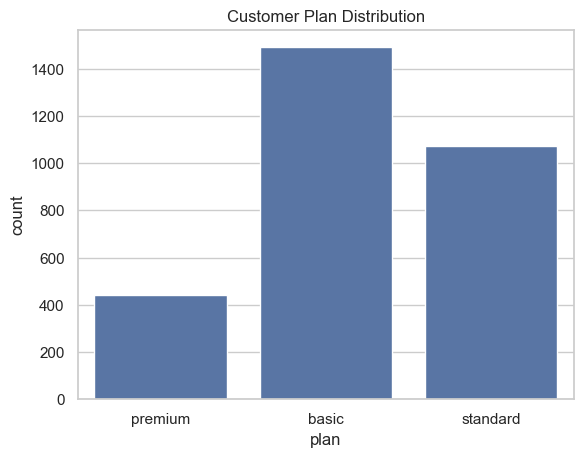

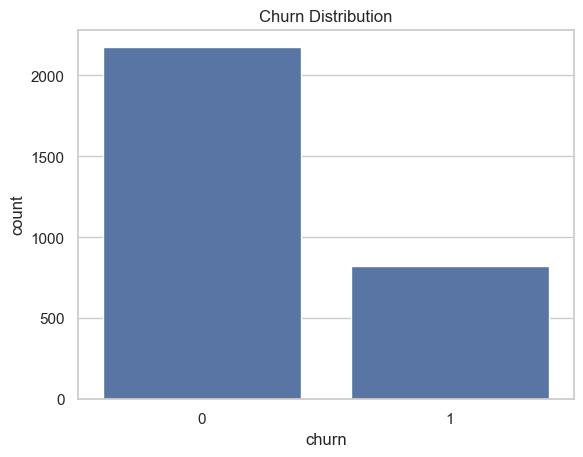

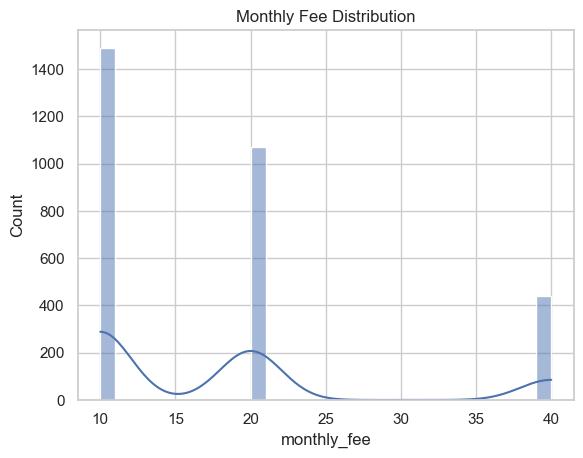

In [7]:
# 🔸 Plan Distribution
sns.countplot(data=customers, x="plan")
plt.title("Customer Plan Distribution")
plt.show()
# 🔸 Monthly Transactions Over Time
# 🔸 Churn Distribution
sns.countplot(data=customers, x="churn")
plt.title("Churn Distribution")
plt.show()
# 🔸 Monthly Fee Distribution
sns.histplot(customers["monthly_fee"], kde=True, bins=30)
plt.title("Monthly Fee Distribution")
plt.show()


📌 CELL 7 — Transaction Behavior

In [8]:
# Total Spending per Customer
trans_agg = transactions.groupby("customer_id").agg(
    total_spend=("amount", "sum"),
    trans_count=("amount", "count"),
    last_transaction=("transaction_date", "max")
).reset_index()

trans_agg.head()


,customer_id,total_spend,trans_count,last_transaction
0,1,440.0,11,2023-12-06
1,2,280.0,28,2023-12-04
2,3,70.0,7,2023-11-19
3,4,230.0,23,2023-10-09
4,5,580.0,29,2023-12-01


📌 CELL 8 — Event Behavior (Login Activity)

In [9]:
events["event_type"].value_counts()
# Logins in last 7 / 30 / 90 days
ref_date = customers["signup_date"].max() + pd.Timedelta(days=365)

events["days_from_ref"] = (ref_date - events["event_date"]).dt.days

login_7 = events[events["days_from_ref"] <= 7].groupby("customer_id").size().rename("logins_7d")
login_30 = events[events["days_from_ref"] <= 30].groupby("customer_id").size().rename("logins_30d")
login_90 = events[events["days_from_ref"] <= 90].groupby("customer_id").size().rename("logins_90d")

logins = pd.concat([login_7, login_30, login_90], axis=1).fillna(0).reset_index()
logins.head()


,customer_id,logins_7d,logins_30d,logins_90d


 📌 CELL 9 — Support Metrics

In [10]:
support_agg = support.groupby("customer_id").agg(
    tickets=("issue_type", "count"),
    avg_resolution=("resolution_days", "mean")
).reset_index()

support_agg.head()


,customer_id,tickets,avg_resolution
0,3,1,1.0
1,8,1,2.0
2,10,1,9.0
3,12,1,4.0
4,16,1,4.0


📌 CELL 10 — Merge All Features

In [11]:
df = customers.merge(trans_agg, on="customer_id", how="left")
df = df.merge(logins, on="customer_id", how="left")
df = df.merge(support_agg, on="customer_id", how="left")

df = df.fillna(0)
df.head()


,customer_id,signup_date,plan,monthly_fee,recency_days,churn,total_spend,trans_count,last_transaction,logins_7d,logins_30d,logins_90d,tickets,avg_resolution
0,1,2023-02-05,premium,40.0,108,0,440.0,11,2023-12-06,0.0,0.0,0.0,0.0,0.0
1,2,2021-09-06,basic,10.0,165,1,280.0,28,2023-12-04,0.0,0.0,0.0,0.0,0.0
2,3,2023-05-14,basic,10.0,132,0,70.0,7,2023-11-19,0.0,0.0,0.0,1.0,1.0
3,4,2021-12-13,basic,10.0,111,0,230.0,23,2023-10-09,0.0,0.0,0.0,0.0,0.0
4,5,2021-08-12,standard,20.0,15,0,580.0,29,2023-12-01,0.0,0.0,0.0,0.0,0.0


📌 CELL 11 — Correlation Heatmap

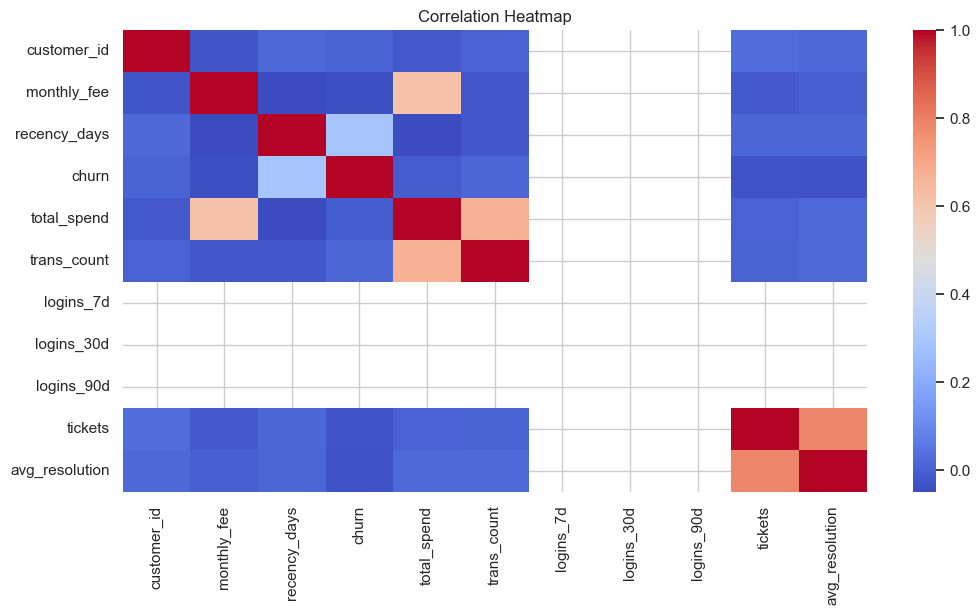

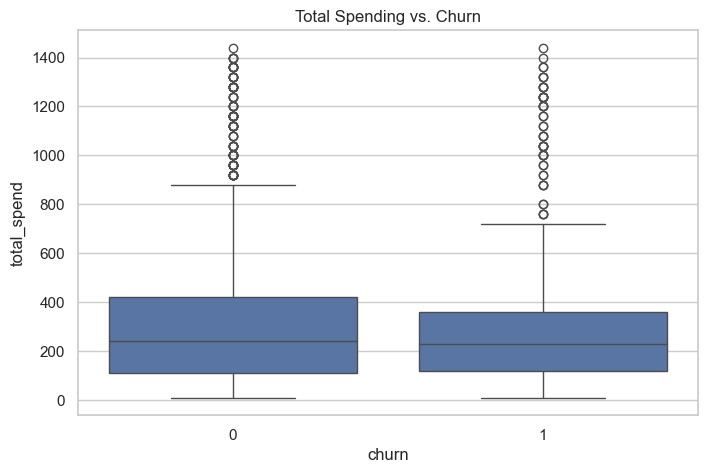

In [14]:
plt.figure(figsize=(12,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(),  cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()
# Spending vs. Churn
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="churn", y="total_spend")
plt.title("Total Spending vs. Churn")
plt.show()

📌 CELL 12 — Prepare Data for ML

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["plan_enc"] = le.fit_transform(df["plan"])

features = [
    "monthly_fee", "recency_days", 
    "total_spend", "trans_count",
    "logins_7d", "logins_30d", "logins_90d",
    "tickets", "avg_resolution",
    "plan_enc"
]

X = df[features]
y = df["churn"].astype(int)

X.head()


,monthly_fee,recency_days,total_spend,trans_count,logins_7d,logins_30d,logins_90d,tickets,avg_resolution,plan_enc
0,40.0,108,440.0,11,0.0,0.0,0.0,0.0,0.0,1
1,10.0,165,280.0,28,0.0,0.0,0.0,0.0,0.0,0
2,10.0,132,70.0,7,0.0,0.0,0.0,1.0,1.0,0
3,10.0,111,230.0,23,0.0,0.0,0.0,0.0,0.0,0
4,20.0,15,580.0,29,0.0,0.0,0.0,0.0,0.0,2


📌 CELL 13 — Train/Test Split & Modeling

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.74      0.84      0.79       544
           1       0.36      0.24      0.29       206

    accuracy                           0.67       750
   macro avg       0.55      0.54      0.54       750
weighted avg       0.64      0.67      0.65       750

ROC-AUC: 0.6079963235294119


📌 CELL 14 — Feature Importance Plot

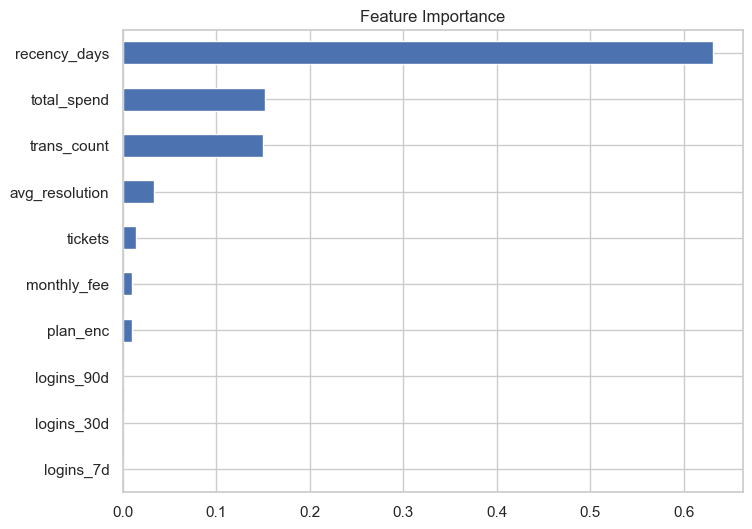

In [18]:
imp = pd.Series(model.feature_importances_, index=features)
imp.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance")
plt.show()


# 2. Load the 4 input files


In [32]:
import os
from pathlib import Path

def safe_read_csv(path, parse_dates=None):
	"""Read CSV if it exists, otherwise return an empty DataFrame and log a warning."""
	if os.path.exists(path):
		try:
			return pd.read_csv(path, parse_dates=parse_dates)
		except Exception as e:
			print(f"❌ Error reading {path}: {e}")
			return pd.DataFrame()
	else:
		print(f"⚠️ File not found: {path}. Creating empty DataFrame.")
		return pd.DataFrame()

base = Path(r"F:\finalYearProject\project_code\inputs").expanduser().resolve()

customers = safe_read_csv(str(base / "customers.csv"), parse_dates=["signup_date"])
transactions = safe_read_csv(str(base / "transactions.csv"), parse_dates=["transaction_date"])
events = safe_read_csv(str(base / "events.csv"), parse_dates=["event_date"])
support = safe_read_csv(str(base / "support.csv"), parse_dates=["ticket_date"])

print("Resolved input directory:", base)

print("✅ Data loaded (missing files result in empty DataFrames)\n")

print("Customers (top 5):")
print(customers.head(), "\n")

print("Transactions (top 5):")
print(transactions.head(), "\n")

print("Events (top 5):")
print(events.head(), "\n")

print("Support  (top 5):")
print(support.head(), "\n")

Resolved input directory: F:\finalYearProject\project_code\inputs
✅ Data loaded (missing files result in empty DataFrames)

Customers (top 5):
   customer_id signup_date      plan  monthly_fee  recency_days  churn
0            1  2023-02-05   premium         40.0           108      0
1            2  2021-09-06     basic         10.0           165      1
2            3  2023-05-14     basic         10.0           132      0
3            4  2021-12-13     basic         10.0           111      0
4            5  2021-08-12  standard         20.0            15      0 

Transactions (top 5):
   customer_id transaction_date  amount
0            1       2023-02-11    40.0
1            1       2023-03-16    40.0
2            1       2023-04-13    40.0
3            1       2023-05-14    40.0
4            1       2023-06-09    40.0 

Events (top 5):
   customer_id event_date event_type
0            1 2023-11-06      login
1            1 2023-09-23      login
2            1 2023-11-16      login
3

# 3. Shapes of each dataset


In [31]:
print("📏 SHAPES")
print("Customers:", customers.shape)
print("Transactions:", transactions.shape)
print("Events:", events.shape)
print("Support:", support.shape, "\n")


📏 SHAPES
Customers: (3000, 6)
Transactions: (51350, 3)
Events: (107842, 4)
Support: (454, 4) 



# 4. Missing values


In [30]:
print("❓ MISSING VALUES\n")

def missing_report(df, name):
    print(f"--- {name} ---")
    print(df.isnull().sum())
    print()

missing_report(customers, "customers")
missing_report(transactions, "transactions")
missing_report(events, "events")
missing_report(support, "support")

❓ MISSING VALUES

--- customers ---
customer_id     0
signup_date     0
plan            0
monthly_fee     0
recency_days    0
churn           0
dtype: int64

--- transactions ---
customer_id         0
transaction_date    0
amount              0
dtype: int64

--- events ---
customer_id      0
event_date       0
event_type       0
days_from_ref    0
dtype: int64

--- support ---
customer_id        0
ticket_date        0
issue_type         0
resolution_days    0
dtype: int64



# 5. Basic statistics on numerical columns (customers)


In [29]:
print("📊 Customers describe():")
print(customers.describe(include="all"))

📊 Customers describe():
        customer_id                 signup_date   plan  monthly_fee  \
count   3000.000000                        3000   3000  3000.000000   
unique          NaN                         NaN      3          NaN   
top             NaN                         NaN  basic          NaN   
freq            NaN                         NaN   1490          NaN   
mean    1500.500000  2022-06-25 19:51:21.600000    NaN    17.966667   
min        1.000000         2021-01-01 00:00:00    NaN    10.000000   
25%      750.750000         2021-09-26 00:00:00    NaN    10.000000   
50%     1500.500000         2022-06-22 00:00:00    NaN    20.000000   
75%     2250.250000         2023-03-21 00:00:00    NaN    20.000000   
max     3000.000000         2023-12-31 00:00:00    NaN    40.000000   
std      866.169729                         NaN    NaN    10.209487   

        recency_days        churn  
count    3000.000000  3000.000000  
unique           NaN          NaN  
top            

# 6. Simple EDA plots (run only if in notebook / interactive)


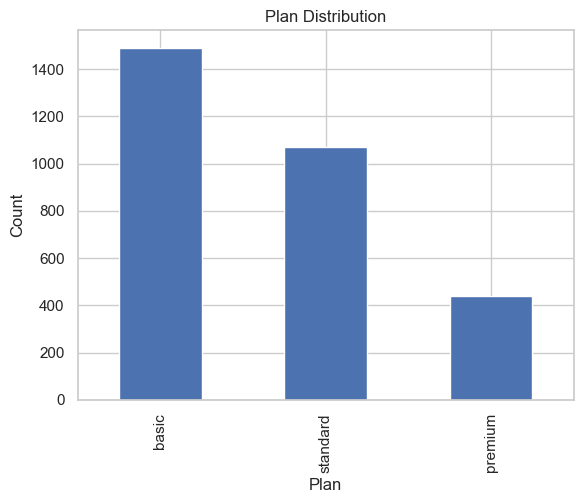

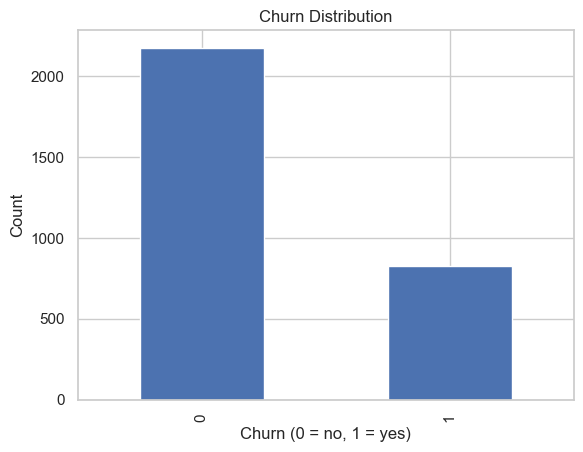

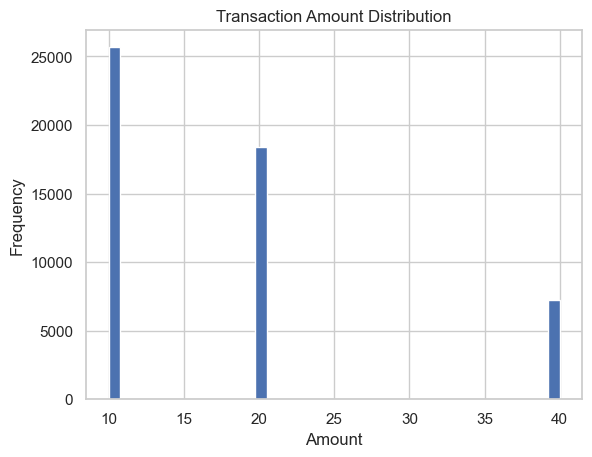

In [28]:
def quick_plots():
    # Plan distribution if 'plan' column exists
    if "plan" in customers.columns:
        customers["plan"].value_counts().plot(kind="bar")
        plt.title("Plan Distribution")
        plt.xlabel("Plan")
        plt.ylabel("Count")
        plt.show()

    # Churn distribution if 'churn' column exists
    if "churn" in customers.columns:
        customers["churn"].value_counts().plot(kind="bar")
        plt.title("Churn Distribution")
        plt.xlabel("Churn (0 = no, 1 = yes)")
        plt.ylabel("Count")
        plt.show()

    # Transaction amount distribution
    if "amount" in transactions.columns:
        transactions["amount"].hist(bins=40)
        plt.title("Transaction Amount Distribution")
        plt.xlabel("Amount")
        plt.ylabel("Frequency")
        plt.show()

# Uncomment this if running in Jupyter or want to see plots:
quick_plots()

# 7. Simple feature engineering preview:
  - Total amount per customer
  - Transaction count per customer
  - Last transaction date

In [27]:
print("\n🧮 Feature engineering preview...")

trans_agg = (
    transactions
    .groupby("customer_id")
    .agg(
        total_amount=("amount", "sum"),
        trans_count=("amount", "count"),
        last_trans_date=("transaction_date", "max"),
    )
    .reset_index()
)

print("Transaction aggregates (top 5):")
print(trans_agg.head(), "\n")

# Merge with customers as an example
customers_fe = customers.merge(trans_agg, on="customer_id", how="left")

print("Customers + basic features (top 5):")
print(customers_fe.head(), "\n")



🧮 Feature engineering preview...
Transaction aggregates (top 5):
   customer_id  total_amount  trans_count last_trans_date
0            1         440.0           11      2023-12-06
1            2         280.0           28      2023-12-04
2            3          70.0            7      2023-11-19
3            4         230.0           23      2023-10-09
4            5         580.0           29      2023-12-01 

Customers + basic features (top 5):
   customer_id signup_date      plan  monthly_fee  recency_days  churn  \
0            1  2023-02-05   premium         40.0           108      0   
1            2  2021-09-06     basic         10.0           165      1   
2            3  2023-05-14     basic         10.0           132      0   
3            4  2021-12-13     basic         10.0           111      0   
4            5  2021-08-12  standard         20.0            15      0   

   total_amount  trans_count last_trans_date  
0         440.0           11      2023-12-06  
1        

# 8. Simple model example: churn prediction using few features
    -(for proper training, use train.py later)

In [26]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

print("🤖 Simple churn model demo...")

# Merge customers with transaction aggregates
df = customers.merge(trans_agg, on="customer_id", how="left")
df = df.fillna(0)


🤖 Simple churn model demo...


# Drop rows where churn is missing (if any)


In [24]:
df = df[~df["churn"].isna()]



# Encode plan if exists


In [22]:
if "plan" in df.columns:
    le_plan = LabelEncoder()
    df["plan_enc"] = le_plan.fit_transform(df["plan"])
else:
    df["plan_enc"] = 0  # fallback

# Fill NaNs from feature engineering


In [21]:
for col in ["total_amount", "trans_count"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        


# Select a small set of features


In [20]:
feature_cols = []
for col in ["monthly_fee", "recency_days", "total_amount", "trans_count", "plan_enc"]:
    if col in df.columns:
        feature_cols.append(col)

X = df[feature_cols]
y = df["churn"].astype(int)

print("Using features:", feature_cols)
print("X shape:", X.shape, "y shape:", y.shape, "\n")

Using features: ['monthly_fee', 'recency_days', 'trans_count', 'plan_enc']
X shape: (3000, 4) y shape: (3000,) 



# Train-test split



In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=200, random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("✅ Classification report:")
print(classification_report(y_test, y_pred))

try:
    auc = roc_auc_score(y_test, y_proba)
    print("ROC-AUC:", round(auc, 4))
except Exception:
    pass

print("\n✅ Notebook-style analysis done.")

✅ Classification report:
              precision    recall  f1-score   support

           0       0.74      0.83      0.78       544
           1       0.35      0.25      0.29       206

    accuracy                           0.67       750
   macro avg       0.55      0.54      0.54       750
weighted avg       0.64      0.67      0.65       750

ROC-AUC: 0.6019

✅ Notebook-style analysis done.


📌 CELL 15 — Save the Model (Optional)

In [ ]:
import joblib
joblib.dump(model, "../models/churn_model_notebook.pkl")
